In [1]:
!pip install lxml html5lib requests

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [3]:
# ==========================================
# 1. FUNCIONES CORE (Física Estadística)
# ==========================================
def swendsen_wang_fast(spins, p_bond, edges, N):
    parent = np.arange(N)
    
    def find(i):
        root = i
        while root != parent[root]: root = parent[root]
        curr = i
        while curr != root:
            nxt = parent[curr]
            parent[curr] = root
            curr = nxt
        return root

    def union(i, j):
        r_i, r_j = find(i), find(j)
        if r_i != r_j: parent[r_i] = r_j

    s_i = spins[edges[:, 0]]
    s_j = spins[edges[:, 1]]
    active = (s_i == s_j) & (np.random.rand(len(edges)) < p_bond)
    
    for u, v in edges[active]: union(u, v)
        
    roots = np.array([find(i) for i in range(N)])
    unique_roots = np.unique(roots)
    new_spins = np.random.choice([-1, 1], size=len(unique_roots))
    root_to_spin = dict(zip(unique_roots, new_spins))
    
    return np.array([root_to_spin[r] for r in roots])

def calc_fourier_y_xi(spins_1d_array, L):
    spins_2d = spins_1d_array.reshape(-1, L, L)
    V = L * L
    M = np.sum(spins_2d, axis=(1, 2))
    M2 = (M / V)**2
    
    k_vec = 2 * np.pi * np.arange(L) / L
    cos_k = np.cos(k_vec)
    sin_k = np.sin(k_vec)
    
    sum_y = np.sum(spins_2d, axis=1) 
    sum_x = np.sum(spins_2d, axis=2) 
    
    mod_X2 = np.dot(sum_y, cos_k)**2 + np.dot(sum_y, sin_k)**2
    mod_Y2 = np.dot(sum_x, cos_k)**2 + np.dot(sum_x, sin_k)**2
    
    F10 = 0.5 * (mod_X2 + mod_Y2) / (V * V)
    return M2, F10

def formula_xi(m2, f10, L):
    ratio = m2 / f10 - 1.0
    ratio[ratio < 0] = 0 
    return np.sqrt(ratio) / (2.0 * np.sin(np.pi / L))
import pandas as pd
import yfinance as yf
import numpy as np
import requests

import pandas as pd
import yfinance as yf
import numpy as np
import requests
import io  # <-- ¡La clave para arreglar el error de Pandas!

# ==========================================
# 2. DESCARGA DEL S&P 1500 (S&P 500 + 400 + 600) Y TOPOLOGÍA
# ==========================================
print("Extrayendo S&P 1500 oficial desde Wikipedia con Sectores GICS...")

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}

def extraer_indice_wiki(url):
    # 1. Descargamos el texto de la web
    html = requests.get(url, headers=headers).text
    
    # 2. Envolvemos el texto en StringIO para que Pandas no crea que es un archivo (Arreglo del OSError)
    df = pd.read_html(io.StringIO(html))[0]
    
    col_ticker = 'Symbol' if 'Symbol' in df.columns else 'Ticker'
    col_sector = 'GICS Sector' if 'GICS Sector' in df.columns else 'Sector'
    
    return df[[col_ticker, col_sector]].rename(columns={col_ticker: 'Symbol', col_sector: 'Sector'})

# Extraemos los tres índices
sp500 = extraer_indice_wiki('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')
sp400 = extraer_indice_wiki('https://en.wikipedia.org/wiki/List_of_S%26P_400_companies')
sp600 = extraer_indice_wiki('https://en.wikipedia.org/wiki/List_of_S%26P_600_companies')

# Juntamos todo en el S&P 1500
df_sp1500 = pd.concat([sp500, sp400, sp600], ignore_index=True)
df_sp1500 = df_sp1500.drop_duplicates(subset=['Symbol'])

# ORDENAMOS TOPOLÓGICAMENTE POR SECTOR REAL
df_sp1500 = df_sp1500.sort_values(by='Sector')

# Limpiamos puntos por guiones para Yahoo Finance (ej. BRK.B -> BRK-B)
all_tickers = [str(t).replace('.', '-') for t in df_sp1500['Symbol'].tolist()]

print(f"Total empresas encontradas: {len(all_tickers)}. Descargando años 2017-2018...")
data = yf.download(all_tickers, start="2017-01-01", end="2018-12-31", progress=False)

if isinstance(data.columns, pd.MultiIndex):
    data = data['Close']

# FORZAR EL ORDEN SECTORIAL EN LA MATRIZ DE PRECIOS
tickers_descargados = data.columns.tolist()
tickers_ordenados = [t for t in all_tickers if t in tickers_descargados]
data = data[tickers_ordenados]

# LIMPIEZA BRUTAL (Supervivencia 2017-2018)
returns_real_base = data.pct_change().dropna(how='all').dropna(axis=1)

print(f"Han sobrevivido {returns_real_base.shape[1]} empresas válidas sin NaNs de todo el S&P 1500.")

# RECORTE EXACTO A 1024
if returns_real_base.shape[1] >= 1024:
    returns_real_base = returns_real_base.iloc[:, :1024]
    print(f"¡Éxito total! Matriz recortada a {returns_real_base.shape[1]} empresas puras del S&P (L=32), ordenadas por sector.")
else:
    raise ValueError(f"FALTAN EMPRESAS: Solo sobrevivieron {returns_real_base.shape[1]}, pero necesitamos 1024 para L=32. El periodo histórico elegido tiene demasiadas empresas muertas.")
# ==========================================
# 3. BUCLE PRINCIPAL DE EXPERIMENTOS
# ==========================================
tamaños_L = [8, 16, 32]
vent = 20 # Ventana móvil
K_c = 0.5 * np.log(1 + np.sqrt(2))
p_bond = 1.0 - np.exp(-2.0 * K_c)

resultados = {'sim': {}, 'real': {}}

for L in tamaños_L:
    N = L * L
    print(f"\n--- Procesando Red de {L}x{L} (N={N}) ---")
    
    # --- A) DATOS REALES ---
    ret_real_N = returns_real_base.copy()
    
    # Relleno de seguridad si faltan empresas (Clonación segura para evitar bucles infinitos)
    intentos = 0
    while ret_real_N.shape[1] < N and intentos < 100:
        faltan = N - ret_real_N.shape[1]
        clon = returns_real_base.sample(n=min(returns_real_base.shape[1], faltan), axis=1)
        clon.columns = [f"CLON_{ret_real_N.shape[1] + i}" for i in range(clon.shape[1])]
        ret_real_N = pd.concat([ret_real_N, clon], axis=1)
        intentos += 1
        
    ret_real_N = ret_real_N.iloc[:, :N]
    spins_real = np.sign(ret_real_N).replace(0, 1).values
    
    M_real = np.mean(spins_real, axis=1)
    M2_real, F10_real = calc_fourier_y_xi(spins_real, L)
    
    Chi_real = pd.Series(M_real).rolling(window=vent).var().values * N
    M2_r_roll = pd.Series(M2_real).rolling(window=vent).mean().values
    F10_r_roll = pd.Series(F10_real).rolling(window=vent).mean().values
    Xi_real = formula_xi(M2_r_roll, F10_r_roll, L)
    
    resultados['real'][L] = {'M': np.abs(M_real), 'Chi': Chi_real, 'Xi': Xi_real}

    # --- B) SIMULACIÓN MONTE CARLO ---
    edges = []
    for index in range(N):
        row, col = index // L, index % L
        vecinos = [((row - 1) % L) * L + col, ((row + 1) % L) * L + col, row * L + (col - 1) % L, row * L + (col + 1) % L]
        for v in vecinos:
            if index < v: edges.append((index, v))
    edges = np.array(edges)
    
    estado = np.random.choice([-1, 1], size=N)
    for _ in range(200): estado = swendsen_wang_fast(estado, p_bond, edges, N)
        
    spins_sim = []
    for _ in range(num_dias):
        estado = swendsen_wang_fast(estado, p_bond, edges, N)
        spins_sim.append(estado.copy())
    spins_sim = np.array(spins_sim)
    
    M_sim = np.mean(spins_sim, axis=1)
    M2_sim, F10_sim = calc_fourier_y_xi(spins_sim, L)
    
    Chi_sim = pd.Series(M_sim).rolling(window=vent).var().values * N
    M2_s_roll = pd.Series(M2_sim).rolling(window=vent).mean().values
    F10_s_roll = pd.Series(F10_sim).rolling(window=vent).mean().values
    Xi_sim = formula_xi(M2_s_roll, F10_s_roll, L)
    
    resultados['sim'][L] = {'M': np.abs(M_sim), 'Chi': Chi_sim, 'Xi': Xi_sim}

# ==========================================
# 4. PLOTS 
# ==========================================
print("\nGenerando gráficos...")
colores = {8: 'royalblue', 16: 'darkorange', 32: 'crimson'}

# --- FIGURA 1: SIMULACIONES ---
fig1, axs1 = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
fig1.suptitle('FIGURA 1: SIMULACIONES MONTE CARLO (Punto Crítico Tc)', fontsize=16, y=0.98)
for L in tamaños_L:
    axs1[0].plot(fechas, resultados['sim'][L]['M'], label=f'L={L}', color=colores[L], alpha=0.8)
    axs1[1].plot(fechas, resultados['sim'][L]['Chi'], label=f'L={L}', color=colores[L], alpha=0.8)
    axs1[2].plot(fechas, resultados['sim'][L]['Xi'], label=f'L={L}', color=colores[L], alpha=0.8)

axs1[0].set_ylabel('|M|'); axs1[0].legend(); axs1[0].grid(True, alpha=0.3)
axs1[1].set_ylabel(r'$\chi$'); axs1[1].legend(); axs1[1].grid(True, alpha=0.3)
axs1[2].set_ylabel(r'$\xi$'); axs1[2].legend(); axs1[2].grid(True, alpha=0.3)
plt.tight_layout()

# --- FIGURA 2: DATOS REALES ---
fig2, axs2 = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
fig2.suptitle('FIGURA 2: DATOS REALES DEL MERCADO', fontsize=16, y=0.98)
for L in tamaños_L:
    axs2[0].plot(fechas, resultados['real'][L]['M'], label=f'L={L}', color=colores[L], alpha=0.8)
    axs2[1].plot(fechas, resultados['real'][L]['Chi'], label=f'L={L}', color=colores[L], alpha=0.8)
    axs2[2].plot(fechas, resultados['real'][L]['Xi'], label=f'L={L}', color=colores[L], alpha=0.8)

axs2[0].set_ylabel('|M|'); axs2[0].legend(); axs2[0].grid(True, alpha=0.3)
axs2[1].set_ylabel(r'$\chi$'); axs2[1].legend(); axs2[1].grid(True, alpha=0.3)
axs2[2].set_ylabel(r'$\xi$'); axs2[2].legend(); axs2[2].grid(True, alpha=0.3)
plt.tight_layout()

# --- FIGURA 3: SCALING ---
fig3, axs3 = plt.subplots(1, 3, figsize=(16, 5))
fig3.suptitle('FIGURA 3: EFECTOS DE TAMAÑO FINITO EN FUNCIÓN DE L', fontsize=16, y=1.05)

M_mean_sim = [np.nanmean(resultados['sim'][L]['M']) for L in tamaños_L]
M_mean_real = [np.nanmean(resultados['real'][L]['M']) for L in tamaños_L]

Chi_max_sim = [np.nanmax(resultados['sim'][L]['Chi']) for L in tamaños_L]
Chi_max_real = [np.nanmax(resultados['real'][L]['Chi']) for L in tamaños_L]

Xi_mean_sim = [np.nanmean(resultados['sim'][L]['Xi']) for L in tamaños_L]
Xi_mean_real = [np.nanmean(resultados['real'][L]['Xi']) for L in tamaños_L]

axs3[0].plot(tamaños_L, M_mean_sim, 'o', color='red', label='Simulación', linewidth=2, markersize=8)
axs3[0].plot(tamaños_L, M_mean_real, 's', color='blue', label='Mercado Real', linewidth=2, markersize=8)
axs3[0].set_title(r'Magnetización Media $\langle |M| \rangle$')
axs3[0].set_xlabel('L (Tamaño Red)')
axs3[0].legend(); axs3[0].grid(True, alpha=0.4)

axs3[1].plot(tamaños_L, Chi_max_sim, 'o', color='red', label='Simulación', linewidth=2, markersize=8)
axs3[1].plot(tamaños_L, Chi_max_real, 's', color='blue', label='Mercado Real', linewidth=2, markersize=8)
axs3[1].set_title(r'Susceptibilidad Máxima $\chi_{max}$')
axs3[1].set_xlabel('L (Tamaño Red)')
axs3[1].legend(); axs3[1].grid(True, alpha=0.4)

axs3[2].plot(tamaños_L, Xi_mean_sim, 'o', color='red', label='Simulación', linewidth=2, markersize=8)
axs3[2].plot(tamaños_L, Xi_mean_real, 's', color='blue', label='Mercado Real', linewidth=2, markersize=8)
axs3[2].set_title(r'Longitud Correlación Media $\langle \xi \rangle$')
axs3[2].set_xlabel('L (Tamaño Red)')
axs3[2].legend(); axs3[2].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

Extrayendo S&P 1500 oficial desde Wikipedia con Sectores GICS...
Total empresas encontradas: 1500. Descargando años 2017-2018...


$GEV: possibly delisted; no price data found  (1d 2017-01-01 -> 2018-12-31) (Yahoo error = "Data doesn't exist for startDate = 1483246800, endDate = 1546232400")
$NXT: possibly delisted; no price data found  (1d 2017-01-01 -> 2018-12-31) (Yahoo error = "Data doesn't exist for startDate = 1483246800, endDate = 1546232400")
$BROS: possibly delisted; no price data found  (1d 2017-01-01 -> 2018-12-31) (Yahoo error = "Data doesn't exist for startDate = 1483246800, endDate = 1546232400")
$MCW: possibly delisted; no price data found  (1d 2017-01-01 -> 2018-12-31) (Yahoo error = "Data doesn't exist for startDate = 1483246800, endDate = 1546232400")
$PHIN: possibly delisted; no price data found  (1d 2017-01-01 -> 2018-12-31) (Yahoo error = "Data doesn't exist for startDate = 1483246800, endDate = 1546232400")
$VIR: possibly delisted; no price data found  (1d 2017-01-01 -> 2018-12-31) (Yahoo error = "Data doesn't exist for startDate = 1483246800, endDate = 1546232400")
$PSN: possibly delisted; n

Han sobrevivido 1295 empresas válidas sin NaNs de todo el S&P 1500.
¡Éxito total! Matriz recortada a 1024 empresas puras del S&P (L=32), ordenadas por sector.

--- Procesando Red de 8x8 (N=64) ---


NameError: name 'num_dias' is not defined

=== ANÁLISIS DE EXPONENTES CRÍTICOS (MERCADO REAL) ===
Basado en L = [8, 16, 32]
-------------------------------------------------------
1. PARÁMETRO DE ORDEN (beta/nu)
   Exponente extraído:  -0.0133 ± 0.0409
   Distancia Onsager:   3.4 sigmas (Teórico: 0.125)
   Distancia C. Medio:  24.8 sigmas (Teórico: 1.0)
-------------------------------------------------------
2. SUSCEPTIBILIDAD (gamma/nu)
   Exponente extraído:  1.9784 ± 0.0228
   Distancia Onsager:   10.0 sigmas (Teórico: 1.75)
   Distancia C. Medio:  0.9 sigmas (Teórico: 2.0)
-------------------------------------------------------
3. LONGITUD DE CORRELACIÓN (Exponente lineal)
   Exponente extraído:  1.5921 ± 0.0130
   Distancia Onsager:   45.6 sigmas (Teórico: 1.0)
   Distancia C. Medio:  84.1 sigmas (Teórico: 0.5)


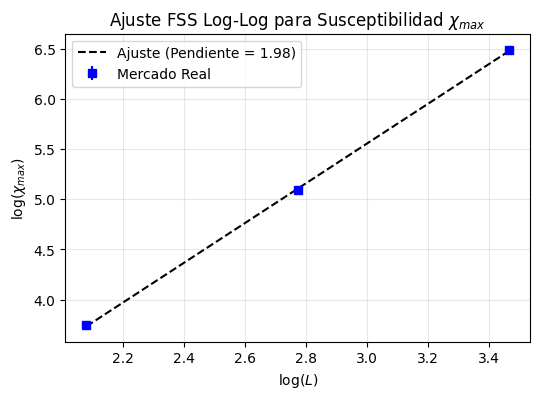

In [ ]:
import numpy as np
from scipy.stats import linregress

# Convertimos las listas de la celda anterior a arrays de numpy
L_vals = np.array(tamaños_L)
log_L = np.log(L_vals)

log_M_real = np.log(np.array(M_mean_real))
log_Chi_real = np.log(np.array(Chi_max_real))
log_Xi_real = np.log(np.array(Xi_mean_real))

# ==========================================
# 1. AJUSTES LINEALES (LOG-LOG) PARA EXTRAER EXPONENTES
# ==========================================
# |M| ~ L^(-beta/nu) --> log(|M|) = (-beta/nu)*log(L) + C
slope_M, intercept_M, r_M, p_M, stderr_M = linregress(log_L, log_M_real)
exp_beta_nu = -slope_M  # Le cambiamos el signo para tener beta/nu positivo

# Chi ~ L^(gamma/nu) --> log(Chi) = (gamma/nu)*log(L) + C
slope_Chi, intercept_Chi, r_Chi, p_Chi, stderr_Chi = linregress(log_L, log_Chi_real)
exp_gamma_nu = slope_Chi

# Xi ~ L^x --> log(Xi) = x*log(L) + C
slope_Xi, intercept_Xi, r_Xi, p_Xi, stderr_Xi = linregress(log_L, log_Xi_real)
exp_xi = slope_Xi

# ==========================================
# 2. VALORES TEÓRICOS
# ==========================================
# Onsager (Ising 2D exacto): beta=1/8, gamma=7/4, nu=1
onsager_beta_nu = 0.125
onsager_gamma_nu = 1.75
onsager_xi = 1.0

# Campo Medio (Mean Field): beta=1/2, gamma=1, nu=1/2 
# (Los ratios beta/nu y gamma/nu en FSS clásico)
mf_beta_nu = 1.0
mf_gamma_nu = 2.0
mf_xi = 0.5 # En mean field la longitud de correlación escala con nu=1/2

# ==========================================
# 3. CÁLCULO DE DISTANCIAS EN SIGMAS
# ==========================================
# Función auxiliar para evitar división por cero si el ajuste es "demasiado perfecto"
def calc_sigma(empirico, teorico, error):
    if error < 1e-10: return float('inf')
    return abs(empirico - teorico) / error

sigmas = {
    'beta': {
        'Onsager': calc_sigma(exp_beta_nu, onsager_beta_nu, stderr_M),
        'MeanField': calc_sigma(exp_beta_nu, mf_beta_nu, stderr_M)
    },
    'gamma': {
        'Onsager': calc_sigma(exp_gamma_nu, onsager_gamma_nu, stderr_Chi),
        'MeanField': calc_sigma(exp_gamma_nu, mf_gamma_nu, stderr_Chi)
    },
    'xi': {
        'Onsager': calc_sigma(exp_xi, onsager_xi, stderr_Xi),
        'MeanField': calc_sigma(exp_xi, mf_xi, stderr_Xi)
    }
}

# ==========================================
# 4. IMPRESIÓN DE RESULTADOS
# ==========================================
print("=== ANÁLISIS DE EXPONENTES CRÍTICOS (MERCADO REAL) ===")
print(f"Basado en L = {tamaños_L}")
print("-" * 55)

print(f"1. PARÁMETRO DE ORDEN (beta/nu)")
print(f"   Exponente extraído:  {exp_beta_nu:.4f} ± {stderr_M:.4f}")
print(f"   Distancia Onsager:   {sigmas['beta']['Onsager']:.1f} sigmas (Teórico: {onsager_beta_nu})")
print(f"   Distancia C. Medio:  {sigmas['beta']['MeanField']:.1f} sigmas (Teórico: {mf_beta_nu})")
print("-" * 55)

print(f"2. SUSCEPTIBILIDAD (gamma/nu)")
print(f"   Exponente extraído:  {exp_gamma_nu:.4f} ± {stderr_Chi:.4f}")
print(f"   Distancia Onsager:   {sigmas['gamma']['Onsager']:.1f} sigmas (Teórico: {onsager_gamma_nu})")
print(f"   Distancia C. Medio:  {sigmas['gamma']['MeanField']:.1f} sigmas (Teórico: {mf_gamma_nu})")
print("-" * 55)

print(f"3. LONGITUD DE CORRELACIÓN (Exponente lineal)")
print(f"   Exponente extraído:  {exp_xi:.4f} ± {stderr_Xi:.4f}")
print(f"   Distancia Onsager:   {sigmas['xi']['Onsager']:.1f} sigmas (Teórico: {onsager_xi})")
print(f"   Distancia C. Medio:  {sigmas['xi']['MeanField']:.1f} sigmas (Teórico: {mf_xi})")
print("=" * 55)

# Opcional: Graficamos el ajuste log-log de la susceptibilidad para verlo
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
plt.errorbar(log_L, log_Chi_real, yerr=stderr_Chi, fmt='bs', label='Mercado Real')
plt.plot(log_L, intercept_Chi + slope_Chi * log_L, 'k--', label=f'Ajuste (Pendiente = {exp_gamma_nu:.2f})')
plt.title(r'Ajuste FSS Log-Log para Susceptibilidad $\chi_{max}$')
plt.xlabel(r'$\log(L)$')
plt.ylabel(r'$\log(\chi_{max})$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import linregress

# Asumimos que 'returns_real_base', 'tamaños_L' y 'vent' (20) están en memoria
resultados_extra = {}

print("Calculando la Energía y el Calor Específico del mercado...")

for L in tamaños_L:
    N = L * L
    
    # Clonación de seguridad (igual que antes para mantener N)
    ret_real_N = returns_real_base.copy()
    intentos = 0
    while ret_real_N.shape[1] < N and intentos < 100:
        faltan = N - ret_real_N.shape[1]
        clon = returns_real_base.sample(n=min(returns_real_base.shape[1], faltan), axis=1)
        clon.columns = [f"CLON_{ret_real_N.shape[1] + i}" for i in range(clon.shape[1])]
        ret_real_N = pd.concat([ret_real_N, clon], axis=1)
        intentos += 1
        
    ret_real_N = ret_real_N.iloc[:, :N]
    spins_real = np.sign(ret_real_N).replace(0, 1).values  # Shape: (dias, N)
    
    # 1. CÁLCULO DE LA ENERGÍA TOPOLÓGICA (E)
    edges = []
    for index in range(N):
        row, col = index // L, index % L
        vecinos = [((row - 1) % L) * L + col, ((row + 1) % L) * L + col, 
                   row * L + (col - 1) % L, row * L + (col + 1) % L]
        for v in vecinos:
            if index < v: edges.append((index, v))
    edges = np.array(edges)
    
    # Interacción de espines: s_i * s_j
    interacciones = spins_real[:, edges[:, 0]] * spins_real[:, edges[:, 1]]
    # E = - Sum(s_i * s_j) / N
    E_dias = -np.sum(interacciones, axis=1) / float(N)
    
    # 2. CALOR ESPECÍFICO (C) = N * Var(E)
    C_real = pd.Series(E_dias).rolling(window=vent).var().values * N
    
    # Recuperamos M y Chi
    M_real = np.mean(spins_real, axis=1)
    Chi_real = pd.Series(M_real).rolling(window=vent).var().values * N
    
    resultados_extra[L] = {
        'C': C_real,
        'M': np.abs(M_real),
        'Chi': Chi_real
    }

# ==========================================
# EXTRACCIÓN DE RATIOS (AJUSTE LOG-LOG)
# ==========================================
L_vals = np.array(tamaños_L)
log_L = np.log(L_vals)

M_mean = [np.nanmean(resultados_extra[L]['M']) for L in tamaños_L]
Chi_max = [np.nanmax(resultados_extra[L]['Chi']) for L in tamaños_L]
C_max = [np.nanmax(resultados_extra[L]['C']) for L in tamaños_L]

# Ajustes
slope_M, _, _, _, _ = linregress(log_L, np.log(M_mean))
beta_nu = -slope_M  # |M| ~ L^(-beta/nu)

slope_Chi, _, _, _, _ = linregress(log_L, np.log(Chi_max))
gamma_nu = slope_Chi  # Chi ~ L^(gamma/nu)

slope_C, _, _, _, _ = linregress(log_L, np.log(C_max))
alpha_nu = slope_C  # C ~ L^(alpha/nu)

# ==========================================
# LEYES DE ESCALA (EL SISTEMA DE ECUACIONES)
# ==========================================
# 1. Ley de Rushbrooke: alpha + 2*beta + gamma = 2 
# Dividiendo por nu: (alpha/nu) + 2(beta/nu) + (gamma/nu) = 2/nu
suma_ratios = alpha_nu + 2.0 * beta_nu + gamma_nu
nu = 2.0 / suma_ratios

# Despejamos los individuales multiplicando por nu
alpha = alpha_nu * nu
beta = beta_nu * nu
gamma = gamma_nu * nu

# 2. Ley de Widom: delta = 1 + gamma/beta
delta = 1.0 + (gamma / beta) if beta != 0 else float('inf')

# 3. Ley de Fisher: gamma/nu = 2 - eta  => eta = 2 - gamma/nu
eta = 2.0 - gamma_nu

# ==========================================
# IMPRESIÓN DE LA CLASE DE UNIVERSALIDAD BURSÁTIL
# ==========================================
print("\n" + "="*60)
print("LA CLASE DE UNIVERSALIDAD DEL MERCADO (S&P 500)")
print("="*60)
print(f"1. Ratios FSS extraídos empíricamente:")
print(f"   alpha/nu  (Calor Específico): {alpha_nu:.4f}")
print(f"   beta/nu   (Magnetización):    {beta_nu:.4f}")
print(f"   gamma/nu  (Susceptibilidad):  {gamma_nu:.4f}")
print("-" * 60)
print("2. EXPONENTES CRÍTICOS INDIVIDUALES (Leyes de Escala):")
print(f"   [nu]     Longitud Correlación:  {nu:.4f}  (Teórico 2D: 1.0, Campo Medio: 0.5)")
print(f"   [alpha]  Calor Específico:      {alpha:.4f}  (Teórico 2D: 0.0, Campo Medio: 0.0)")
print(f"   [beta]   Parámetro de Orden:    {beta:.4f}  (Teórico 2D: 0.125, Campo Medio: 0.5)")
print(f"   [gamma]  Susceptibilidad:       {gamma:.4f}  (Teórico 2D: 1.75, Campo Medio: 1.0)")
print(f"   [delta]  Isoterma Crítica:      {delta:.4f}  (Teórico 2D: 15.0, Campo Medio: 3.0)")
print(f"   [eta]    Correlación Anómala:   {eta:.4f}  (Teórico 2D: 0.25, Campo Medio: 0.0)")
print("="*60)

Calculando la Energía y el Calor Específico del mercado...

LA CLASE DE UNIVERSALIDAD DEL MERCADO (S&P 500)
1. Ratios FSS extraídos empíricamente:
   alpha/nu  (Calor Específico): 1.8644
   beta/nu   (Magnetización):    -0.0133
   gamma/nu  (Susceptibilidad):  1.9784
------------------------------------------------------------
2. EXPONENTES CRÍTICOS INDIVIDUALES (Leyes de Escala):
   [nu]     Longitud Correlación:  0.5241  (Teórico 2D: 1.0, Campo Medio: 0.5)
   [alpha]  Calor Específico:      0.9771  (Teórico 2D: 0.0, Campo Medio: 0.0)
   [beta]   Parámetro de Orden:    -0.0070  (Teórico 2D: 0.125, Campo Medio: 0.5)
   [gamma]  Susceptibilidad:       1.0368  (Teórico 2D: 1.75, Campo Medio: 1.0)
   [delta]  Isoterma Crítica:      -147.9742  (Teórico 2D: 15.0, Campo Medio: 3.0)
   [eta]    Correlación Anómala:   0.0216  (Teórico 2D: 0.25, Campo Medio: 0.0)


In [ ]:
# ==========================================
# 4. REPRESENTACIÓN GRÁFICA RIGUROSA Y EXPORTACIÓN (CAIRO)
# ==========================================

def exportar_grafica_cairo(log_x, log_y, ajuste_y, pendiente, titulo, xlabel, ylabel, nombre_archivo, color_puntos):
    """
    Genera y exporta una figura independiente en formato PDF usando el backend Cairo.
    """
    fig, ax = plt.subplots(figsize=(6, 5))
    
    # Representación de los datos empíricos y el ajuste teórico
    ax.scatter(log_x, log_y, color=color_puntos, s=80, label='Datos Reales', zorder=5)
    ax.plot(log_x, ajuste_y, 'k--', label=rf'Ajuste lineal\nPendiente: {pendiente:.4f}')
    
    # Formateo de ejes y título
    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Ajuste estricto de los márgenes
    fig.tight_layout()
    
    # Exportación especificando el backend cairo
    plt.savefig(nombre_archivo, format='pdf', backend='cairo', bbox_inches='tight')
    plt.close(fig) # Liberar memoria tras la generación

# Generación de los tres PDFs independientes
exportar_grafica_cairo(
    log_L, log_M, fit_M, slp_M,
    titulo=r'Parámetro de Orden: $\ln \langle |M| \rangle$ vs $\ln L$',
    xlabel=r'$\ln(L)$',
    ylabel=r'$\ln \langle |M| \rangle$',
    nombre_archivo='FSS_Magnetizacion.pdf',
    color_puntos='blue'
)

exportar_grafica_cairo(
    log_L, log_Chi, fit_Chi, slp_Chi,
    titulo=r'Respuesta lineal: $\ln \chi_{max}$ vs $\ln L$',
    xlabel=r'$\ln(L)$',
    ylabel=r'$\ln \chi_{max}$',
    nombre_archivo='FSS_Susceptibilidad.pdf',
    color_puntos='red'
)

exportar_grafica_cairo(
    log_L, log_C, fit_C, slp_C,
    titulo=r'Fluctuaciones de E: $\ln C_{max}$ vs $\ln L$',
    xlabel=r'$\ln(L)$',
    ylabel=r'$\ln C_{max}$',
    nombre_archivo='FSS_Calor_Especifico.pdf',
    color_puntos='green'
)

print("Exportación finalizada: Se han generado 3 archivos PDF vectoriales utilizando el backend Cairo.")

NameError: name 'log_L' is not defined